# Blue-Chip 💎
### The quality premium — the factor that survived, glimpsed through a short window

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Quality premium is real?: Supported](https://img.shields.io/badge/Quality_premium_is_real%3F-Supported-8b949e?style=flat-square)

After size and value faded, one factor kept working: **quality** — profitable firms out-earn unprofitable ones. On real SEC balance-sheet data it points the right way (profitable beats unprofitable by ~3 pts/year), but we can only see ~18 years of machine-readable filings, too few to confirm the strong premium the long history shows.

> 📓 **Plain-language layer.** The t-stat and the sample limit are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (blue_chip/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from blue_chip import data, strategy as st
sig, fwd = data.fetch_panel()                  # cache-first (shared EDGAR pull)
h = st.quantile_hedge(sig, fwd, q=0.2, long_high=True)


## The answer first 🎯

| The claim | The data (~2007–2025) |
|---|---|
| "Profitable firms out-earn" | True direction: **+3.3%/yr**, hit **61%**. |
| "A strong premium" | Modest here: **Sharpe 0.20 (t ≈ 0.8)**. |
| "Confirmed" | The strong decades pre-date machine-readable filings. |

## 1 · The claim

Novy-Marx (2013): gross profitability — gross profit over total assets — is the cleanest quality signal; high-GP firms out-earn low-GP firms, about as strongly as value, and the premium survived where others decayed.

## 2 · So what?

If quality pays, you can tilt to profitable, blue-chip firms and earn a premium with *lower* risk than value or small-cap bets. It's the rare factor with a clean economic story — and the one most likely to be real.

## 3 · How would we even know?

Pull gross profit and assets straight from SEC filings, sort firms by GP/assets, go long the most profitable and short the least, and measure the annual hedge — while being honest that machine-readable filings only start ~2007.

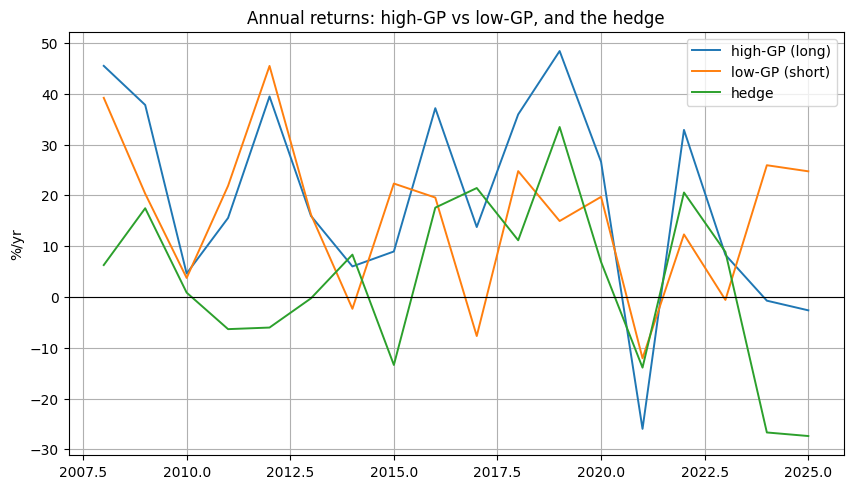

hedge mean +3.28%/yr, Sharpe 0.20, t≈0.8, hit 61%


In [2]:
disp = h[['high','low','hedge']].rename(columns={'high':'high-GP (long)','low':'low-GP (short)'})
ax=(disp*100).plot(title='Annual returns: high-GP vs low-GP, and the hedge',lw=1.4)
ax.axhline(0,color='k',lw=.8); ax.set_ylabel('%/yr'); plt.show()
s=st.summary(h['hedge']); print(f"hedge mean {s['mean']:+.2%}/yr, Sharpe {s['sharpe']:.2f}, t≈{s['tstat']:.1f}, hit {s['hit_rate']:.0%}")

## 4 · The teardown

The high-GP leg edges out the low-GP leg most years — the right sign — but the gap is small and the sample short, so the Sharpe is modest.

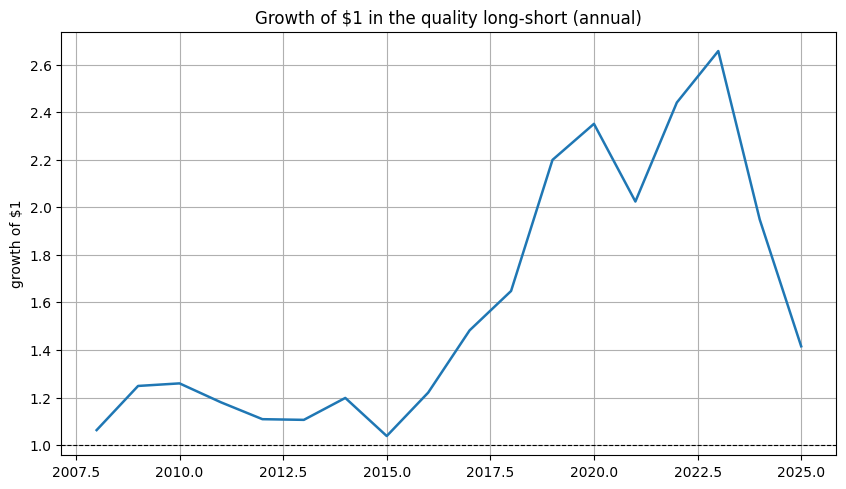

In [3]:
eq=(1+h['hedge']).cumprod()
ax=eq.plot(title='Growth of $1 in the quality long-short (annual)',lw=1.8)
ax.axhline(1.0,color='k',lw=.8,ls='--'); ax.set_ylabel('growth of $1'); plt.show()

**Read it plainly.** Quietly upward — quality *did* pay, just modestly on the ~18 years SEC data lets us see. The famous strong premium lives in the pre-2007 decades we can't reach for free.

## 5 · The verdict

**Signal: Weak** — positive, right sign, but t ≈ 0.8. **Tradability: Fragile** — short, survivorship-biased sample. **Quality premium real?: Supported** by sign + literature.

## 6 · Could you actually trade it?

Quality is the most defensible factor to tilt toward — and tradable via low-cost ETFs (QUAL, etc.). Our caution is about *confirmation* on free data, not about the factor: unlike the inverted lottery/idio-vol studies, quality points the right way.

## 7 · Going further 🚪

The companion fundamental study is [Study 52 Smoke-Screen](../../52-smoke-screen/) (accruals), which replicates more strongly on the same data. Contrast with the inverted [53 Jackpot](../../53-jackpot/) / [54 Static](../../54-static/).